##Task 1: Vectorized Multi-Layer Perceptron (MLP) Forward & Backward Pass from Scratch

#Objective:
 Master the mathematical foundations of gradient descent by deriving and implementing multi-layer backpropagation equations using raw matrix calculus from first
principles.

#Required Tech Stack:
Pure NumPy, Python 3.10+, Jupyter Notebook.

#Task Description:
 Students must implement a fully connected neural network with arbitrary hidden layer dimensions from scratch. The code must handle batch-wise forward passes, calculate cross-entropy loss, derive layer-wise local Jacobians, and execute backward weight adjustments using raw 3D matrix transformations without PyTorch's autograd.


Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

Create XOR Dataset

In [2]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
], dtype=np.float32)

y = np.array([0,1,1,0])

num_classes = 2

Y = np.eye(num_classes)[y]

print(X)
print(Y)

[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
[[1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]]


Network Configuration

In [3]:
input_size = 2
hidden_size = 8
output_size = 2

learning_rate = 0.1
epochs = 5000

Initialize Weights

In [4]:
W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))

Activation Functions

In [5]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    exp = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)

Cross Entropy Loss

In [6]:
def cross_entropy(predictions, targets):
    epsilon = 1e-15
    predictions = np.clip(predictions, epsilon, 1 - epsilon)
    loss = -np.sum(targets * np.log(predictions))
    return loss / len(targets)

Forward Propagation

In [7]:
def forward(X):

    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)

    cache = (Z1, A1, Z2, A2)

    return A2, cache

Backward Propagation

In [8]:
def backward(X, Y, cache):

    global W1, b1, W2, b2

    Z1, A1, Z2, A2 = cache

    m = X.shape[0]

    dZ2 = (A2 - Y) / m

    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)

    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

Training

In [9]:
losses = []

for epoch in range(epochs):

    predictions, cache = forward(X)

    loss = cross_entropy(predictions, Y)

    backward(X, Y, cache)

    losses.append(loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch}  Loss = {loss:.6f}")

Epoch 0  Loss = 0.691786
Epoch 500  Loss = 0.057668
Epoch 1000  Loss = 0.015517
Epoch 1500  Loss = 0.008476
Epoch 2000  Loss = 0.005738
Epoch 2500  Loss = 0.004306
Epoch 3000  Loss = 0.003434
Epoch 3500  Loss = 0.002848
Epoch 4000  Loss = 0.002430
Epoch 4500  Loss = 0.002115


Loss Curve

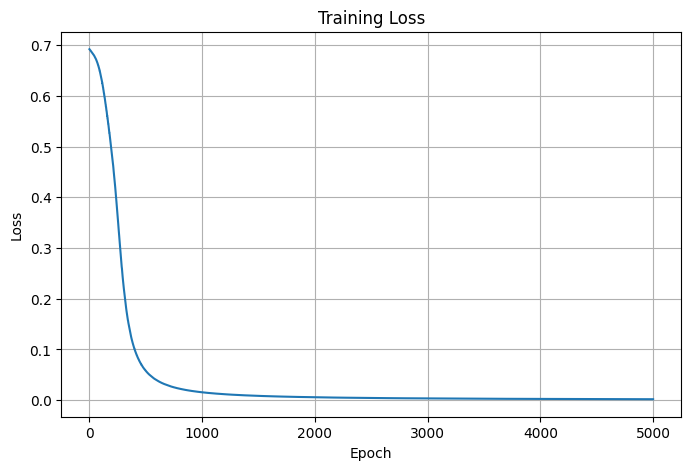

In [10]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

Prediction

In [11]:
predictions, _ = forward(X)

predicted_class = np.argmax(predictions, axis=1)

print("Predictions:")
print(predicted_class)

print()

print("Actual:")
print(y)

Predictions:
[0 1 1 0]

Actual:
[0 1 1 0]


Accuracy

In [12]:
accuracy = np.mean(predicted_class == y) * 100

print(f"Accuracy : {accuracy:.2f}%")

Accuracy : 100.00%
